In [117]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)


In [118]:
summary_path = Path("../results/corruption_benchmark/summaries/class_metrics_raw.csv")
if not summary_path.exists():
    summary_path = Path("results/corruption_benchmark/summaries/class_metrics_raw.csv")

raw = pd.read_csv(summary_path)

MODELS = ["adaptclip", "anomalyclip", "winclip"]
DATASETS = ["mvtec", "visa", "btad"]
CONDITIONS = ["clean", "gaussian_noise", "motion_blur", "brightness"]
METRICS = [col for col in ["I-AUROC", "P-AUROC", "P-AP", "P-F1max"] if col in raw.columns]

raw.head()


,model,dataset,split,corruption,severity,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,adaptclip,btad,all,brightness,3,1,0.96,0.93,0.52,0.55
1,adaptclip,btad,all,brightness,3,2,0.84,0.93,0.60,0.60
2,adaptclip,btad,all,brightness,3,3,0.98,0.92,0.10,0.21
3,adaptclip,btad,all,clean,0,1,0.96,0.93,0.51,0.54
4,adaptclip,btad,all,clean,0,2,0.81,0.93,0.60,0.62


In [119]:
def condition_table(model, dataset, corruption, split="all", decimals=2):
    cols = ["class"] + METRICS
    result = (
        raw[
            raw["model"].eq(model)
            & raw["dataset"].eq(dataset)
            & raw["corruption"].eq(corruption)
            & raw["split"].eq(split)
        ][cols]
        .sort_values("class")
        .reset_index(drop=True)
    )
    result[METRICS] = result[METRICS].round(decimals)
    return result


def condition_block(model, dataset, split="all", decimals=2):
    return {condition: condition_table(model, dataset, condition, split, decimals) for condition in CONDITIONS}


def display_condition_block(model, dataset, split="all", decimals=2):
    display(Markdown(f"### [{model} - {dataset}]"))
    for condition in CONDITIONS:
        display(Markdown(f"**[{condition}]**"))
        display(condition_table(model, dataset, condition, split, decimals))


def drop_table(model, dataset, corruption, metric="I-AUROC", split="all", decimals=2):
    clean = condition_table(model, dataset, "clean", split, decimals=6)[["class", metric]]
    corrupt = condition_table(model, dataset, corruption, split, decimals=6)[["class", metric]]
    out = clean.merge(corrupt, on="class", suffixes=("_clean", "_corrupted"))
    out = out.rename(columns={f"{metric}_clean": "clean", f"{metric}_corrupted": "corrupted"})
    out.insert(0, "corruption", corruption)
    out["drop"] = out["clean"] - out["corrupted"]
    out["relative_drop"] = out["drop"] / out["clean"]
    out[["clean", "corrupted", "drop", "relative_drop"]] = out[["clean", "corrupted", "drop", "relative_drop"]].round(decimals)
    return out.sort_values("drop", ascending=False).reset_index(drop=True)


def all_drop_table(model, dataset, metric="I-AUROC", split="all", decimals=2):
    pieces = [drop_table(model, dataset, corruption, metric, split, decimals) for corruption in CONDITIONS if corruption != "clean"]
    return pd.concat(pieces, ignore_index=True)




def assign_difficulty_bins(scores, score_col, hard_ratio=0.30, normal_ratio=0.40):
    scores = scores.sort_values(score_col, ascending=True).reset_index(drop=True).copy()
    scores.insert(0, "rank", scores.index + 1)
    n = len(scores)
    hard_cut = int(round(n * hard_ratio))
    normal_cut = hard_cut + int(round(n * normal_ratio))
    scores["difficulty"] = "easy"
    scores.loc[scores["rank"].le(normal_cut), "difficulty"] = "normal"
    scores.loc[scores["rank"].le(hard_cut), "difficulty"] = "hard"
    scores["rank_percentile"] = (scores["rank"] / n).round(2)
    return scores


def category_scores_by_condition(corruption="clean", metric="I-AUROC", split="all", decimals=2):
    score_col = f"mean_{metric}"
    scores = (
        raw[raw["split"].eq(split) & raw["corruption"].eq(corruption)]
        .groupby(["dataset", "class"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: score_col})
    )
    scores = assign_difficulty_bins(scores, score_col)
    scores[score_col] = scores[score_col].round(decimals)
    return scores[["rank", "rank_percentile", "difficulty", "dataset", "class", score_col]]


def clean_difficulty_by_category(metric="I-AUROC", split="all", decimals=2):
    return category_scores_by_condition("clean", metric, split, decimals)


def difficulty_shift_by_corruption(corruption, metric="I-AUROC", split="all", decimals=2):
    score_col = f"mean_{metric}"
    clean = category_scores_by_condition("clean", metric, split, decimals=6).rename(
        columns={
            "rank": "clean_rank",
            "rank_percentile": "clean_percentile",
            "difficulty": "clean_difficulty",
            score_col: "clean_score",
        }
    )
    corrupt = category_scores_by_condition(corruption, metric, split, decimals=6).rename(
        columns={
            "rank": "corrupt_rank",
            "rank_percentile": "corrupt_percentile",
            "difficulty": "corrupt_difficulty",
            score_col: "corrupt_score",
        }
    )
    out = clean.merge(corrupt, on=["dataset", "class"])
    out["score_drop"] = out["clean_score"] - out["corrupt_score"]
    out["rank_shift"] = out["corrupt_rank"] - out["clean_rank"]
    out["difficulty_changed"] = out["clean_difficulty"].ne(out["corrupt_difficulty"])
    value_cols = ["clean_score", "corrupt_score", "score_drop"]
    out[value_cols] = out[value_cols].round(decimals)
    return out.sort_values(["difficulty_changed", "rank_shift"], ascending=[False, False]).reset_index(drop=True)


def all_difficulty_shifts(metric="I-AUROC", split="all", decimals=2):
    rows = []
    for corruption in [c for c in CONDITIONS if c != "clean"]:
        item = difficulty_shift_by_corruption(corruption, metric, split, decimals)
        item.insert(0, "corruption", corruption)
        rows.append(item)
    return pd.concat(rows, ignore_index=True)

def difficulty_by_category(metric="I-AUROC", split="all", decimals=2):
    return clean_difficulty_by_category(metric, split, decimals)


def latex(df, caption=None, label=None):
    print(df.to_latex(index=False, escape=False, caption=caption, label=label))


def latex_condition_tables(model, dataset):
    for condition in CONDITIONS:
        print(f"% {model} / {dataset} / {condition}")
        latex(
            condition_table(model, dataset, condition),
            caption=f"{model} {condition} results on {dataset}.",
            label=f"tab:{model}_{dataset}_{condition}",
        )
        print()

show_all_result = condition_table


## Condition Tables
Each cell returns four tables: clean, gaussian_noise, motion_blur, brightness.

## adaptclip / mvtec

In [120]:
display_condition_block("adaptclip", "mvtec")


### [adaptclip - mvtec]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.91,0.92,0.60,0.56
1,cable,0.84,0.77,0.16,0.25
2,capsule,0.95,0.96,0.35,0.40
3,carpet,1.00,0.99,0.68,0.67
4,grid,0.99,0.97,0.28,0.40
5,hazelnut,0.95,0.98,0.51,0.54
6,leather,1.00,0.99,0.28,0.44
7,metal_nut,0.94,0.77,0.28,0.35
8,pill,0.87,0.90,0.33,0.35
9,screw,0.86,0.98,0.29,0.34


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.94,0.92,0.61,0.56
1,cable,0.71,0.81,0.16,0.22
2,capsule,0.80,0.95,0.22,0.27
3,carpet,1.00,0.99,0.70,0.68
4,grid,0.97,0.95,0.32,0.39
5,hazelnut,0.86,0.96,0.30,0.35
6,leather,1.00,0.99,0.34,0.49
7,metal_nut,0.76,0.75,0.22,0.34
8,pill,0.62,0.84,0.13,0.20
9,screw,0.78,0.97,0.21,0.29


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.91,0.94,0.68,0.63
1,cable,0.83,0.79,0.15,0.21
2,capsule,0.82,0.95,0.30,0.35
3,carpet,0.93,0.96,0.64,0.63
4,grid,0.88,0.90,0.17,0.28
5,hazelnut,0.75,0.96,0.27,0.33
6,leather,1.00,0.99,0.26,0.42
7,metal_nut,0.89,0.79,0.31,0.36
8,pill,0.75,0.88,0.25,0.30
9,screw,0.60,0.95,0.14,0.19


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.88,0.92,0.60,0.57
1,cable,0.79,0.79,0.17,0.26
2,capsule,0.93,0.97,0.35,0.40
3,carpet,0.99,0.99,0.69,0.67
4,grid,0.98,0.96,0.28,0.38
5,hazelnut,0.89,0.98,0.51,0.53
6,leather,1.00,0.99,0.29,0.45
7,metal_nut,0.92,0.76,0.27,0.33
8,pill,0.89,0.89,0.31,0.32
9,screw,0.89,0.98,0.28,0.35


## adaptclip / visa

In [121]:
display_condition_block("adaptclip", "visa")


### [adaptclip - visa]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.87,0.99,0.22,0.36
1,capsules,0.94,0.94,0.33,0.44
2,cashew,0.86,0.94,0.23,0.28
3,chewinggum,0.97,0.99,0.83,0.78
4,fryum,0.92,0.95,0.26,0.34
5,macaroni1,0.83,0.98,0.16,0.23
6,macaroni2,0.72,0.98,0.02,0.06
7,pcb1,0.84,0.96,0.16,0.25
8,pcb2,0.66,0.93,0.12,0.20
9,pcb3,0.65,0.88,0.05,0.11


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.73,0.95,0.15,0.27
1,capsules,0.89,0.94,0.27,0.39
2,cashew,0.81,0.96,0.31,0.37
3,chewinggum,0.93,0.99,0.75,0.72
4,fryum,0.86,0.96,0.32,0.40
5,macaroni1,0.88,0.97,0.18,0.27
6,macaroni2,0.66,0.97,0.01,0.04
7,pcb1,0.84,0.94,0.09,0.15
8,pcb2,0.62,0.93,0.12,0.19
9,pcb3,0.61,0.88,0.04,0.09


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.88,0.98,0.23,0.31
1,capsules,0.86,0.91,0.18,0.29
2,cashew,0.90,0.92,0.24,0.31
3,chewinggum,0.96,0.99,0.74,0.70
4,fryum,0.82,0.95,0.28,0.35
5,macaroni1,0.87,0.96,0.15,0.24
6,macaroni2,0.67,0.96,0.01,0.02
7,pcb1,0.60,0.95,0.12,0.19
8,pcb2,0.53,0.92,0.08,0.20
9,pcb3,0.60,0.88,0.04,0.07


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.88,0.98,0.18,0.31
1,capsules,0.94,0.95,0.40,0.50
2,cashew,0.87,0.95,0.24,0.30
3,chewinggum,0.96,0.99,0.80,0.76
4,fryum,0.90,0.95,0.27,0.34
5,macaroni1,0.87,0.98,0.24,0.34
6,macaroni2,0.66,0.98,0.03,0.07
7,pcb1,0.80,0.96,0.19,0.28
8,pcb2,0.65,0.93,0.11,0.19
9,pcb3,0.59,0.87,0.05,0.12


## adaptclip / btad

In [122]:
display_condition_block("adaptclip", "btad")


### [adaptclip - btad]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.96,0.93,0.51,0.54
1,2,0.81,0.93,0.60,0.62
2,3,0.96,0.95,0.14,0.23


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.95,0.94,0.55,0.57
1,2,0.75,0.92,0.63,0.61
2,3,0.99,0.94,0.18,0.25


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.98,0.94,0.52,0.55
1,2,0.74,0.92,0.49,0.54
2,3,0.91,0.95,0.23,0.28


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.96,0.93,0.52,0.55
1,2,0.84,0.93,0.60,0.60
2,3,0.98,0.92,0.10,0.21


## anomalyclip / mvtec

In [123]:
display_condition_block("anomalyclip", "mvtec")


### [anomalyclip - mvtec]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.93,0.86,0.59,0.57
1,cable,0.88,0.94,0.46,0.46
2,capsule,0.90,0.92,0.28,0.36
3,carpet,1.00,0.99,0.63,0.62
4,grid,0.99,0.97,0.34,0.44
5,hazelnut,0.98,0.95,0.46,0.52
6,leather,1.00,0.99,0.36,0.40
7,metal_nut,0.96,0.91,0.65,0.64
8,pill,0.82,0.78,0.32,0.38
9,screw,0.84,0.95,0.27,0.33


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.92,0.86,0.55,0.54
1,cable,0.82,0.90,0.35,0.37
2,capsule,0.77,0.86,0.17,0.26
3,carpet,0.99,0.97,0.63,0.63
4,grid,0.94,0.92,0.34,0.41
5,hazelnut,0.94,0.95,0.37,0.42
6,leather,1.00,0.99,0.39,0.44
7,metal_nut,0.83,0.88,0.45,0.50
8,pill,0.69,0.80,0.16,0.20
9,screw,0.70,0.90,0.22,0.30


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.90,0.86,0.58,0.60
1,cable,0.87,0.91,0.34,0.37
2,capsule,0.79,0.77,0.17,0.27
3,carpet,0.84,0.92,0.55,0.61
4,grid,0.88,0.83,0.22,0.33
5,hazelnut,0.86,0.95,0.38,0.43
6,leather,1.00,0.99,0.39,0.43
7,metal_nut,0.88,0.87,0.47,0.51
8,pill,0.79,0.74,0.16,0.23
9,screw,0.56,0.62,0.09,0.17


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.91,0.89,0.60,0.57
1,cable,0.80,0.93,0.45,0.45
2,capsule,0.84,0.89,0.24,0.35
3,carpet,1.00,0.99,0.65,0.64
4,grid,0.97,0.96,0.36,0.45
5,hazelnut,0.96,0.93,0.44,0.51
6,leather,1.00,0.99,0.38,0.42
7,metal_nut,0.92,0.91,0.66,0.65
8,pill,0.81,0.69,0.27,0.34
9,screw,0.89,0.92,0.25,0.33


## anomalyclip / visa

In [124]:
display_condition_block("anomalyclip", "visa")


### [anomalyclip - visa]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.88,0.98,0.20,0.33
1,capsules,0.91,0.96,0.28,0.36
2,cashew,0.96,0.96,0.22,0.29
3,chewinggum,0.98,0.99,0.51,0.56
4,fryum,0.96,0.93,0.19,0.26
5,macaroni1,0.89,0.98,0.17,0.25
6,macaroni2,0.78,0.98,0.07,0.12
7,pcb1,0.91,0.94,0.09,0.15
8,pcb2,0.69,0.91,0.10,0.17
9,pcb3,0.77,0.86,0.05,0.13


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.75,0.92,0.15,0.27
1,capsules,0.86,0.94,0.23,0.31
2,cashew,0.87,0.96,0.29,0.40
3,chewinggum,0.93,0.98,0.58,0.58
4,fryum,0.93,0.92,0.17,0.24
5,macaroni1,0.82,0.96,0.14,0.21
6,macaroni2,0.64,0.97,0.02,0.06
7,pcb1,0.92,0.90,0.06,0.12
8,pcb2,0.65,0.90,0.09,0.16
9,pcb3,0.73,0.84,0.06,0.14


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.85,0.96,0.21,0.32
1,capsules,0.82,0.92,0.18,0.29
2,cashew,0.88,0.96,0.22,0.27
3,chewinggum,0.94,0.98,0.52,0.54
4,fryum,0.91,0.94,0.21,0.29
5,macaroni1,0.82,0.97,0.19,0.28
6,macaroni2,0.71,0.96,0.01,0.03
7,pcb1,0.88,0.93,0.12,0.22
8,pcb2,0.42,0.89,0.07,0.17
9,pcb3,0.66,0.81,0.03,0.09


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.88,0.96,0.17,0.31
1,capsules,0.92,0.97,0.38,0.45
2,cashew,0.96,0.97,0.28,0.36
3,chewinggum,0.97,0.99,0.54,0.55
4,fryum,0.94,0.93,0.19,0.26
5,macaroni1,0.82,0.97,0.19,0.26
6,macaroni2,0.63,0.98,0.05,0.13
7,pcb1,0.89,0.93,0.07,0.10
8,pcb2,0.68,0.91,0.09,0.16
9,pcb3,0.73,0.84,0.06,0.14


## anomalyclip / btad

In [125]:
display_condition_block("anomalyclip", "btad")


### [anomalyclip - btad]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.87,0.62,0.11,0.15
1,2,0.87,0.90,0.54,0.58
2,3,0.94,0.91,0.24,0.33


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.90,0.76,0.16,0.20
1,2,0.77,0.87,0.52,0.52
2,3,0.93,0.92,0.19,0.30


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.97,0.63,0.13,0.18
1,2,0.76,0.74,0.26,0.30
2,3,0.91,0.82,0.14,0.22


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.79,0.66,0.13,0.19
1,2,0.83,0.88,0.50,0.53
2,3,0.95,0.93,0.31,0.39


## winclip / mvtec

In [126]:
display_condition_block("winclip", "mvtec")


### [winclip - mvtec]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.41,0.54,0.10,0.12
1,cable,0.48,0.61,0.04,0.08
2,capsule,0.48,0.38,0.01,0.02
3,carpet,0.46,0.24,0.01,0.03
4,grid,0.52,0.48,0.01,0.01
5,hazelnut,0.62,0.40,0.02,0.04
6,leather,0.55,0.33,0.00,0.01
7,metal_nut,0.50,0.31,0.08,0.21
8,pill,0.54,0.15,0.02,0.06
9,screw,0.39,0.43,0.00,0.00


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.53,0.55,0.06,0.12
1,cable,0.52,0.55,0.03,0.07
2,capsule,0.51,0.49,0.01,0.02
3,carpet,0.35,0.20,0.01,0.03
4,grid,0.52,0.47,0.01,0.01
5,hazelnut,0.59,0.62,0.04,0.09
6,leather,0.38,0.37,0.00,0.01
7,metal_nut,0.48,0.42,0.09,0.21
8,pill,0.43,0.32,0.02,0.06
9,screw,0.28,0.63,0.00,0.01


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.63,0.65,0.13,0.17
1,cable,0.48,0.59,0.04,0.07
2,capsule,0.61,0.28,0.01,0.02
3,carpet,0.44,0.32,0.01,0.03
4,grid,0.45,0.49,0.01,0.01
5,hazelnut,0.60,0.46,0.02,0.04
6,leather,0.60,0.35,0.00,0.01
7,metal_nut,0.52,0.29,0.08,0.21
8,pill,0.56,0.18,0.02,0.06
9,screw,0.28,0.45,0.00,0.00


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,bottle,0.87,0.66,0.11,0.17
1,cable,0.57,0.49,0.03,0.06
2,capsule,0.46,0.43,0.01,0.02
3,carpet,0.58,0.32,0.01,0.03
4,grid,0.38,0.45,0.01,0.01
5,hazelnut,0.53,0.21,0.01,0.04
6,leather,0.57,0.36,0.00,0.01
7,metal_nut,0.42,0.27,0.07,0.21
8,pill,0.55,0.21,0.02,0.06
9,screw,0.45,0.60,0.00,0.01


## winclip / visa

In [127]:
display_condition_block("winclip", "visa")


### [winclip - visa]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.61,0.76,0.00,0.02
1,capsules,0.65,0.42,0.00,0.01
2,cashew,0.35,0.56,0.01,0.03
3,chewinggum,0.36,0.38,0.00,0.01
4,fryum,0.52,0.61,0.03,0.06
5,macaroni1,0.35,0.77,0.00,0.00
6,macaroni2,0.50,0.78,0.00,0.00
7,pcb1,0.55,0.57,0.01,0.01
8,pcb2,0.72,0.63,0.00,0.01
9,pcb3,0.49,0.48,0.00,0.01


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.51,0.77,0.00,0.01
1,capsules,0.59,0.43,0.00,0.01
2,cashew,0.42,0.57,0.01,0.03
3,chewinggum,0.50,0.34,0.00,0.01
4,fryum,0.55,0.74,0.05,0.10
5,macaroni1,0.39,0.80,0.00,0.00
6,macaroni2,0.50,0.83,0.00,0.00
7,pcb1,0.57,0.40,0.00,0.01
8,pcb2,0.72,0.50,0.00,0.00
9,pcb3,0.49,0.70,0.01,0.01


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.63,0.72,0.00,0.01
1,capsules,0.49,0.43,0.00,0.01
2,cashew,0.38,0.24,0.01,0.02
3,chewinggum,0.55,0.25,0.00,0.01
4,fryum,0.52,0.49,0.02,0.05
5,macaroni1,0.44,0.60,0.00,0.01
6,macaroni2,0.57,0.70,0.00,0.00
7,pcb1,0.60,0.41,0.00,0.01
8,pcb2,0.70,0.38,0.00,0.00
9,pcb3,0.47,0.46,0.00,0.01


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,candle,0.54,0.62,0.00,0.02
1,capsules,0.59,0.46,0.00,0.01
2,cashew,0.05,0.22,0.01,0.02
3,chewinggum,0.47,0.14,0.00,0.01
4,fryum,0.45,0.38,0.02,0.05
5,macaroni1,0.39,0.38,0.00,0.00
6,macaroni2,0.53,0.66,0.00,0.00
7,pcb1,0.53,0.59,0.01,0.02
8,pcb2,0.33,0.49,0.00,0.00
9,pcb3,0.64,0.48,0.00,0.01


## winclip / btad

In [128]:
display_condition_block("winclip", "btad")


### [winclip - btad]

**[clean]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.55,0.46,0.03,0.06
1,2,0.56,0.37,0.04,0.10
2,3,0.48,0.42,0.00,0.01


**[gaussian_noise]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.50,0.50,0.03,0.06
1,2,0.38,0.27,0.03,0.10
2,3,0.36,0.40,0.00,0.00


**[motion_blur]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.49,0.45,0.03,0.06
1,2,0.47,0.48,0.05,0.10
2,3,0.31,0.39,0.00,0.00


**[brightness]**

,class,I-AUROC,P-AUROC,P-AP,P-F1max
0,1,0.39,0.45,0.03,0.06
1,2,0.49,0.44,0.05,0.10
2,3,0.48,0.36,0.00,0.00


## Clean-to-Corruption Drop
Drop is clean I-AUROC minus corrupted I-AUROC. Larger positive values mean more degradation.

## Drop: adaptclip / mvtec

In [129]:
all_drop_table("adaptclip", "mvtec")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,pill,0.87,0.62,0.24,0.28
1,gaussian_noise,metal_nut,0.94,0.76,0.18,0.19
2,gaussian_noise,capsule,0.95,0.80,0.15,0.16
3,gaussian_noise,cable,0.84,0.71,0.12,0.15
4,gaussian_noise,transistor,0.89,0.77,0.12,0.14
5,gaussian_noise,hazelnut,0.95,0.86,0.09,0.09
6,gaussian_noise,screw,0.86,0.78,0.08,0.09
7,gaussian_noise,zipper,0.99,0.94,0.05,0.05
8,gaussian_noise,grid,0.99,0.97,0.02,0.02
9,gaussian_noise,wood,0.99,0.96,0.02,0.02


## Drop: adaptclip / visa

In [130]:
all_drop_table("adaptclip", "visa")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,candle,0.87,0.73,0.14,0.16
1,gaussian_noise,fryum,0.92,0.86,0.06,0.07
2,gaussian_noise,macaroni2,0.72,0.66,0.06,0.08
3,gaussian_noise,capsules,0.94,0.89,0.05,0.05
4,gaussian_noise,cashew,0.86,0.81,0.05,0.05
5,gaussian_noise,chewinggum,0.97,0.93,0.04,0.04
6,gaussian_noise,pcb2,0.66,0.62,0.04,0.06
7,gaussian_noise,pcb3,0.65,0.61,0.04,0.06
8,gaussian_noise,pipe_fryum,0.97,0.95,0.02,0.02
9,gaussian_noise,pcb4,0.97,0.96,0.01,0.01


## Drop: adaptclip / btad

In [131]:
all_drop_table("adaptclip", "btad")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,2,0.81,0.75,0.06,0.07
1,gaussian_noise,1,0.96,0.95,0.01,0.01
2,gaussian_noise,3,0.96,0.99,-0.03,-0.03
3,motion_blur,2,0.81,0.74,0.07,0.09
4,motion_blur,3,0.96,0.91,0.05,0.05
5,motion_blur,1,0.96,0.98,-0.02,-0.02
6,brightness,1,0.96,0.96,0.00,0.00
7,brightness,3,0.96,0.98,-0.02,-0.02
8,brightness,2,0.81,0.84,-0.03,-0.04


## Drop: anomalyclip / mvtec

In [132]:
all_drop_table("anomalyclip", "mvtec")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,transistor,0.87,0.64,0.23,0.26
1,gaussian_noise,screw,0.84,0.70,0.15,0.17
2,gaussian_noise,capsule,0.90,0.77,0.13,0.15
3,gaussian_noise,pill,0.82,0.69,0.13,0.16
4,gaussian_noise,metal_nut,0.96,0.83,0.12,0.13
5,gaussian_noise,toothbrush,0.93,0.83,0.10,0.11
6,gaussian_noise,zipper,0.98,0.91,0.07,0.07
7,gaussian_noise,cable,0.88,0.82,0.06,0.07
8,gaussian_noise,grid,0.99,0.94,0.05,0.05
9,gaussian_noise,hazelnut,0.98,0.94,0.03,0.03


## Drop: anomalyclip / visa

In [133]:
all_drop_table("anomalyclip", "visa")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,macaroni2,0.78,0.64,0.14,0.18
1,gaussian_noise,candle,0.88,0.75,0.13,0.15
2,gaussian_noise,cashew,0.96,0.87,0.09,0.09
3,gaussian_noise,capsules,0.91,0.86,0.06,0.06
4,gaussian_noise,macaroni1,0.89,0.82,0.06,0.07
5,gaussian_noise,chewinggum,0.98,0.93,0.05,0.05
6,gaussian_noise,pcb2,0.69,0.65,0.04,0.05
7,gaussian_noise,pcb3,0.77,0.73,0.04,0.05
8,gaussian_noise,fryum,0.96,0.93,0.02,0.02
9,gaussian_noise,pipe_fryum,0.95,0.93,0.02,0.02


## Drop: anomalyclip / btad

In [134]:
all_drop_table("anomalyclip", "btad")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,2,0.87,0.77,0.10,0.11
1,gaussian_noise,3,0.94,0.93,0.01,0.01
2,gaussian_noise,1,0.87,0.90,-0.03,-0.03
3,motion_blur,2,0.87,0.76,0.11,0.12
4,motion_blur,3,0.94,0.91,0.02,0.02
5,motion_blur,1,0.87,0.97,-0.09,-0.11
6,brightness,1,0.87,0.79,0.08,0.09
7,brightness,2,0.87,0.83,0.04,0.04
8,brightness,3,0.94,0.95,-0.01,-0.01


## Drop: winclip / mvtec

In [135]:
all_drop_table("winclip", "mvtec")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,leather,0.55,0.38,0.17,0.31
1,gaussian_noise,carpet,0.46,0.35,0.11,0.24
2,gaussian_noise,pill,0.54,0.43,0.11,0.20
3,gaussian_noise,screw,0.39,0.28,0.11,0.29
4,gaussian_noise,hazelnut,0.62,0.59,0.02,0.04
5,gaussian_noise,metal_nut,0.50,0.48,0.02,0.05
6,gaussian_noise,zipper,0.58,0.56,0.01,0.02
7,gaussian_noise,grid,0.52,0.52,-0.00,-0.00
8,gaussian_noise,capsule,0.48,0.51,-0.03,-0.07
9,gaussian_noise,cable,0.48,0.52,-0.04,-0.09


## Drop: winclip / visa

In [136]:
all_drop_table("winclip", "visa")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,pipe_fryum,0.46,0.34,0.12,0.26
1,gaussian_noise,candle,0.61,0.51,0.10,0.17
2,gaussian_noise,capsules,0.65,0.59,0.06,0.09
3,gaussian_noise,macaroni2,0.50,0.50,-0.00,-0.01
4,gaussian_noise,pcb2,0.72,0.72,0.00,0.00
5,gaussian_noise,pcb3,0.49,0.49,0.00,0.01
6,gaussian_noise,fryum,0.52,0.55,-0.02,-0.05
7,gaussian_noise,pcb1,0.55,0.57,-0.02,-0.03
8,gaussian_noise,macaroni1,0.35,0.39,-0.04,-0.12
9,gaussian_noise,cashew,0.35,0.42,-0.07,-0.19


## Drop: winclip / btad

In [137]:
all_drop_table("winclip", "btad")


,corruption,class,clean,corrupted,drop,relative_drop
0,gaussian_noise,2,0.56,0.38,0.18,0.32
1,gaussian_noise,3,0.48,0.36,0.12,0.24
2,gaussian_noise,1,0.55,0.50,0.04,0.08
3,motion_blur,3,0.48,0.31,0.18,0.36
4,motion_blur,2,0.56,0.47,0.08,0.15
5,motion_blur,1,0.55,0.49,0.05,0.09
6,brightness,1,0.55,0.39,0.16,0.28
7,brightness,2,0.56,0.49,0.07,0.13
8,brightness,3,0.48,0.48,-0.00,-0.00


## Clean-Based Difficulty Ranking
Difficulty is assigned using clean I-AUROC only: bottom 30% hard, middle 40% normal, top 30% easy. The shift tables below compare whether corruption changes each category rank or difficulty bin.


In [138]:
clean_clean_difficulty_i_auroc = clean_difficulty_by_category("I-AUROC")
clean_clean_difficulty_i_auroc


,rank,rank_percentile,difficulty,dataset,class,mean_I-AUROC
0,1,0.03,hard,visa,pcb3,0.64
1,2,0.07,hard,visa,macaroni2,0.66
2,3,0.10,hard,visa,macaroni1,0.69
3,4,0.13,hard,visa,pcb2,0.69
4,5,0.17,hard,mvtec,screw,0.70
5,6,0.20,hard,visa,cashew,0.72
6,7,0.23,hard,mvtec,transistor,0.73
7,8,0.27,hard,mvtec,cable,0.73
8,9,0.30,hard,mvtec,pill,0.74
9,10,0.33,normal,btad,2,0.74


## Difficulty Shift Under Corruption
Positive rank_shift means the category became easier relative to others; negative rank_shift means it moved toward harder ranks. difficulty_changed marks categories crossing hard/normal/easy boundaries.

In [139]:
difficulty_shift_by_corruption("gaussian_noise")


,clean_rank,clean_percentile,clean_difficulty,dataset,class,clean_score,corrupt_rank,corrupt_percentile,corrupt_difficulty,corrupt_score,score_drop,rank_shift,difficulty_changed
0,11,0.37,normal,mvtec,bottle,0.75,25,0.83,easy,0.80,-0.05,14,True
1,3,0.10,hard,visa,macaroni1,0.69,12,0.40,normal,0.70,-0.01,9,True
2,13,0.43,normal,visa,chewinggum,0.77,22,0.73,easy,0.79,-0.02,9,True
3,6,0.20,hard,visa,cashew,0.72,13,0.43,normal,0.70,0.02,7,True
4,22,0.73,easy,mvtec,carpet,0.82,18,0.60,normal,0.78,0.04,-4,True
5,10,0.33,normal,btad,2,0.74,5,0.17,hard,0.64,0.11,-5,True
6,27,0.90,easy,visa,capsules,0.83,20,0.67,normal,0.78,0.05,-7,True
7,16,0.53,normal,visa,candle,0.79,7,0.23,hard,0.66,0.13,-9,True
8,12,0.40,normal,visa,pcb1,0.77,17,0.57,normal,0.78,-0.01,5,False
9,23,0.77,easy,mvtec,wood,0.83,28,0.93,easy,0.83,-0.00,5,False


In [140]:
difficulty_shift_by_corruption("motion_blur")


,clean_rank,clean_percentile,clean_difficulty,dataset,class,clean_score,corrupt_rank,corrupt_percentile,corrupt_difficulty,corrupt_score,score_drop,rank_shift,difficulty_changed
0,11,0.37,normal,mvtec,bottle,0.75,26,0.87,easy,0.81,-0.06,15,True
1,13,0.43,normal,visa,chewinggum,0.77,28,0.93,easy,0.82,-0.05,15,True
2,18,0.60,normal,btad,1,0.79,27,0.90,easy,0.81,-0.02,9,True
3,14,0.47,normal,mvtec,toothbrush,0.77,22,0.73,easy,0.77,0.01,8,True
4,16,0.53,normal,visa,candle,0.79,24,0.80,easy,0.79,-0.00,8,True
5,3,0.10,hard,visa,macaroni1,0.69,10,0.33,normal,0.71,-0.02,7,True
6,6,0.20,hard,visa,cashew,0.72,11,0.37,normal,0.72,0.01,5,True
7,8,0.27,hard,mvtec,cable,0.73,13,0.43,normal,0.73,0.00,5,True
8,10,0.33,normal,btad,2,0.74,6,0.20,hard,0.66,0.09,-4,True
9,22,0.73,easy,mvtec,carpet,0.82,18,0.60,normal,0.74,0.08,-4,True


In [141]:
difficulty_shift_by_corruption("brightness")


,clean_rank,clean_percentile,clean_difficulty,dataset,class,clean_score,corrupt_rank,corrupt_percentile,corrupt_difficulty,corrupt_score,score_drop,rank_shift,difficulty_changed
0,11,0.37,normal,mvtec,bottle,0.75,30,1.00,easy,0.89,-0.14,19,True
1,14,0.47,normal,mvtec,toothbrush,0.77,23,0.77,easy,0.81,-0.03,9,True
2,5,0.17,hard,mvtec,screw,0.70,12,0.40,normal,0.75,-0.05,7,True
3,9,0.30,hard,mvtec,pill,0.74,14,0.47,normal,0.75,-0.01,5,True
4,17,0.57,normal,btad,3,0.79,22,0.73,easy,0.80,-0.01,5,True
5,10,0.33,normal,btad,2,0.74,9,0.30,hard,0.72,0.02,-1,True
6,26,0.87,easy,mvtec,grid,0.83,18,0.60,normal,0.78,0.06,-8,True
7,28,0.93,easy,mvtec,hazelnut,0.85,19,0.63,normal,0.79,0.05,-9,True
8,29,0.97,easy,mvtec,zipper,0.85,20,0.67,normal,0.79,0.06,-9,True
9,18,0.60,normal,btad,1,0.79,6,0.20,hard,0.72,0.08,-12,True


In [142]:
all_difficulty_shifts()


,corruption,clean_rank,clean_percentile,clean_difficulty,dataset,class,clean_score,corrupt_rank,corrupt_percentile,corrupt_difficulty,corrupt_score,score_drop,rank_shift,difficulty_changed
0,gaussian_noise,11,0.37,normal,mvtec,bottle,0.75,25,0.83,easy,0.80,-0.05,14,True
1,gaussian_noise,3,0.10,hard,visa,macaroni1,0.69,12,0.40,normal,0.70,-0.01,9,True
2,gaussian_noise,13,0.43,normal,visa,chewinggum,0.77,22,0.73,easy,0.79,-0.02,9,True
3,gaussian_noise,6,0.20,hard,visa,cashew,0.72,13,0.43,normal,0.70,0.02,7,True
4,gaussian_noise,22,0.73,easy,mvtec,carpet,0.82,18,0.60,normal,0.78,0.04,-4,True
5,gaussian_noise,10,0.33,normal,btad,2,0.74,5,0.17,hard,0.64,0.11,-5,True
6,gaussian_noise,27,0.90,easy,visa,capsules,0.83,20,0.67,normal,0.78,0.05,-7,True
7,gaussian_noise,16,0.53,normal,visa,candle,0.79,7,0.23,hard,0.66,0.13,-9,True
8,gaussian_noise,12,0.40,normal,visa,pcb1,0.77,17,0.57,normal,0.78,-0.01,5,False
9,gaussian_noise,23,0.77,easy,mvtec,wood,0.83,28,0.93,easy,0.83,-0.00,5,False


## Overleaf LaTeX Export
Run the cell you need and paste the printed LaTeX table into Overleaf.

In [143]:
latex(condition_table("anomalyclip", "visa", "clean"), caption="AnomalyCLIP clean results on VisA.", label="tab:anomalyclip_visa_clean")


\begin{table}
\caption{AnomalyCLIP clean results on VisA.}
\label{tab:anomalyclip_visa_clean}
\begin{tabular}{lrrrr}
\toprule
class & I-AUROC & P-AUROC & P-AP & P-F1max \\
\midrule
candle & 0.880000 & 0.980000 & 0.200000 & 0.330000 \\
capsules & 0.910000 & 0.960000 & 0.280000 & 0.360000 \\
cashew & 0.960000 & 0.960000 & 0.220000 & 0.290000 \\
chewinggum & 0.980000 & 0.990000 & 0.510000 & 0.560000 \\
fryum & 0.960000 & 0.930000 & 0.190000 & 0.260000 \\
macaroni1 & 0.890000 & 0.980000 & 0.170000 & 0.250000 \\
macaroni2 & 0.780000 & 0.980000 & 0.070000 & 0.120000 \\
pcb1 & 0.910000 & 0.940000 & 0.090000 & 0.150000 \\
pcb2 & 0.690000 & 0.910000 & 0.100000 & 0.170000 \\
pcb3 & 0.770000 & 0.860000 & 0.050000 & 0.130000 \\
pcb4 & 0.980000 & 0.950000 & 0.310000 & 0.350000 \\
pipe_fryum & 0.950000 & 0.960000 & 0.200000 & 0.310000 \\
\bottomrule
\end{tabular}
\end{table}



In [144]:
latex(all_drop_table("anomalyclip", "visa"), caption="AnomalyCLIP I-AUROC drops on VisA.", label="tab:anomalyclip_visa_drop")


\begin{table}
\caption{AnomalyCLIP I-AUROC drops on VisA.}
\label{tab:anomalyclip_visa_drop}
\begin{tabular}{llrrrr}
\toprule
corruption & class & clean & corrupted & drop & relative_drop \\
\midrule
gaussian_noise & macaroni2 & 0.780000 & 0.640000 & 0.140000 & 0.180000 \\
gaussian_noise & candle & 0.880000 & 0.750000 & 0.130000 & 0.150000 \\
gaussian_noise & cashew & 0.960000 & 0.870000 & 0.090000 & 0.090000 \\
gaussian_noise & capsules & 0.910000 & 0.860000 & 0.060000 & 0.060000 \\
gaussian_noise & macaroni1 & 0.890000 & 0.820000 & 0.060000 & 0.070000 \\
gaussian_noise & chewinggum & 0.980000 & 0.930000 & 0.050000 & 0.050000 \\
gaussian_noise & pcb2 & 0.690000 & 0.650000 & 0.040000 & 0.050000 \\
gaussian_noise & pcb3 & 0.770000 & 0.730000 & 0.040000 & 0.050000 \\
gaussian_noise & fryum & 0.960000 & 0.930000 & 0.020000 & 0.020000 \\
gaussian_noise & pipe_fryum & 0.950000 & 0.930000 & 0.020000 & 0.020000 \\
gaussian_noise & pcb4 & 0.980000 & 0.960000 & 0.010000 & 0.010000 \\
gaussian_n

In [145]:
latex(clean_difficulty_i_auroc, caption="Category difficulty ranking by mean I-AUROC.", label="tab:clean_difficulty_i_auroc")


NameError: name 'clean_difficulty_i_auroc' is not defined

## Export All Tables
This writes CSV and LaTeX files for every condition table, every drop table, and the difficulty ranking.

In [146]:
def export_all_tables(output_dir=Path("overleaf_tables")):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for model in MODELS:
        for dataset in DATASETS:
            for condition in CONDITIONS:
                table = condition_table(model, dataset, condition)
                stem = f"{model}_{dataset}_{condition}"
                table.to_csv(output_dir / f"{stem}.csv", index=False)
                (output_dir / f"{stem}.tex").write_text(
                    table.to_latex(
                        index=False,
                        escape=False,
                        caption=f"{model} {condition} results on {dataset}.",
                        label=f"tab:{stem}",
                    )
                )

            drops = all_drop_table(model, dataset)
            drop_stem = f"{model}_{dataset}_i_auroc_drop"
            drops.to_csv(output_dir / f"{drop_stem}.csv", index=False)
            (output_dir / f"{drop_stem}.tex").write_text(
                drops.to_latex(
                    index=False,
                    escape=False,
                    caption=f"{model} clean-to-corruption I-AUROC drops on {dataset}.",
                    label=f"tab:{drop_stem}",
                )
            )

    difficulty = difficulty_by_category("I-AUROC")
    difficulty.to_csv(output_dir / "clean_difficulty_i_auroc.csv", index=False)
    (output_dir / "clean_difficulty_i_auroc.tex").write_text(
        difficulty.to_latex(
            index=False,
            escape=False,
            caption="Category difficulty ranking by mean I-AUROC.",
            label="tab:clean_difficulty_i_auroc",
        )
    )
    return output_dir

export_all_tables()


PosixPath('overleaf_tables')

## Drop Visualization
These plots use clean-to-corruption I-AUROC drop. Larger positive values mean the corruption hurts performance more.

In [147]:
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="matplotlib-"))

import matplotlib.pyplot as plt


def mean_drop_summary(metric="I-AUROC"):
    rows = []
    for model in MODELS:
        for dataset in DATASETS:
            drops = all_drop_table(model, dataset, metric=metric)
            summary = drops.groupby("corruption", as_index=False)["drop"].mean()
            summary.insert(0, "dataset", dataset)
            summary.insert(0, "model", model)
            rows.append(summary)
    return pd.concat(rows, ignore_index=True)


mean_drop_i_auroc = mean_drop_summary("I-AUROC")
mean_drop_i_auroc


,model,dataset,corruption,drop
0,adaptclip,mvtec,brightness,0.00
1,adaptclip,mvtec,gaussian_noise,0.07
2,adaptclip,mvtec,motion_blur,0.08
3,adaptclip,visa,brightness,0.02
4,adaptclip,visa,gaussian_noise,0.04
5,adaptclip,visa,motion_blur,0.05
6,adaptclip,btad,brightness,-0.02
7,adaptclip,btad,gaussian_noise,0.01
8,adaptclip,btad,motion_blur,0.03
9,anomalyclip,mvtec,brightness,0.02


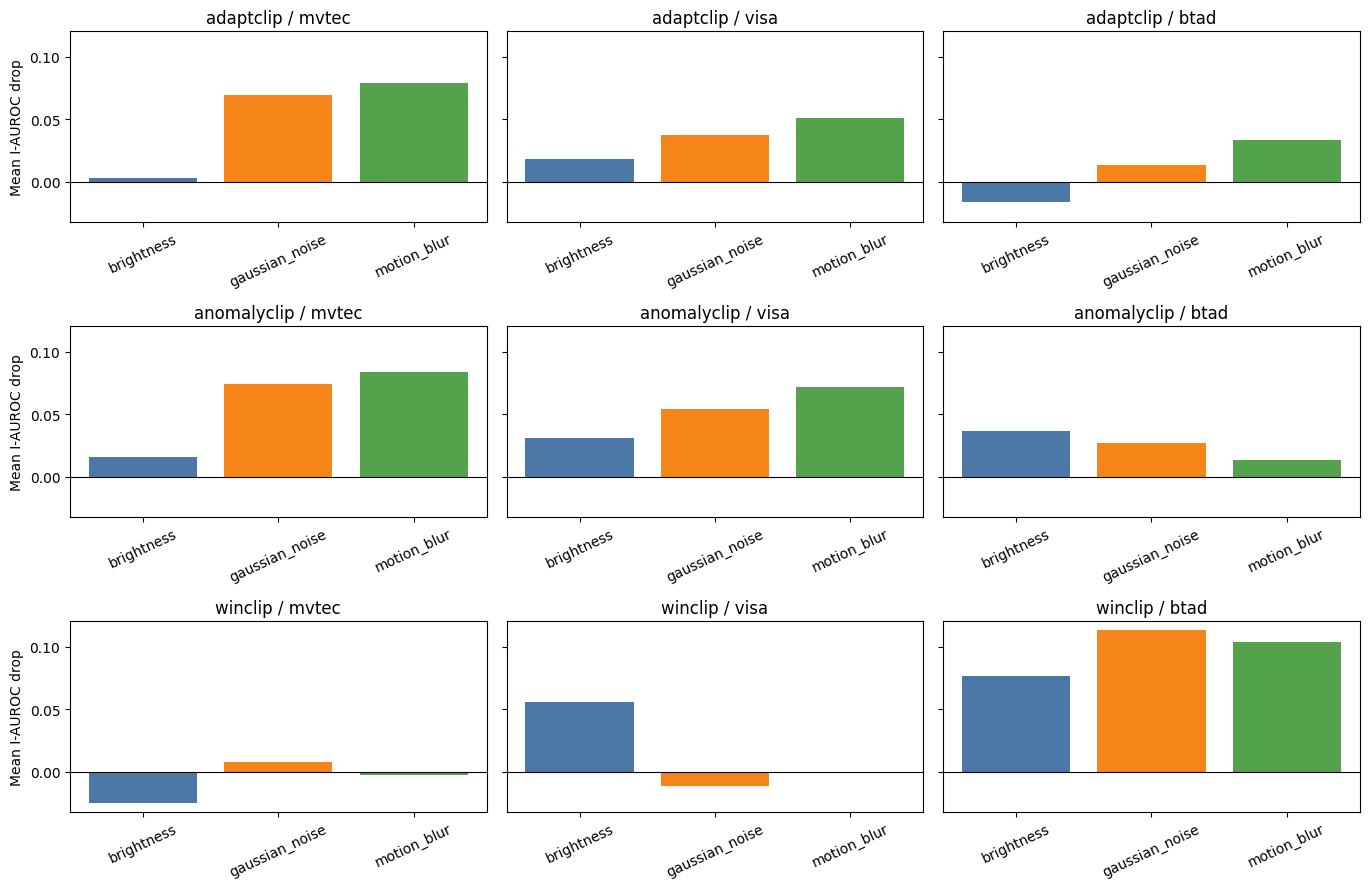

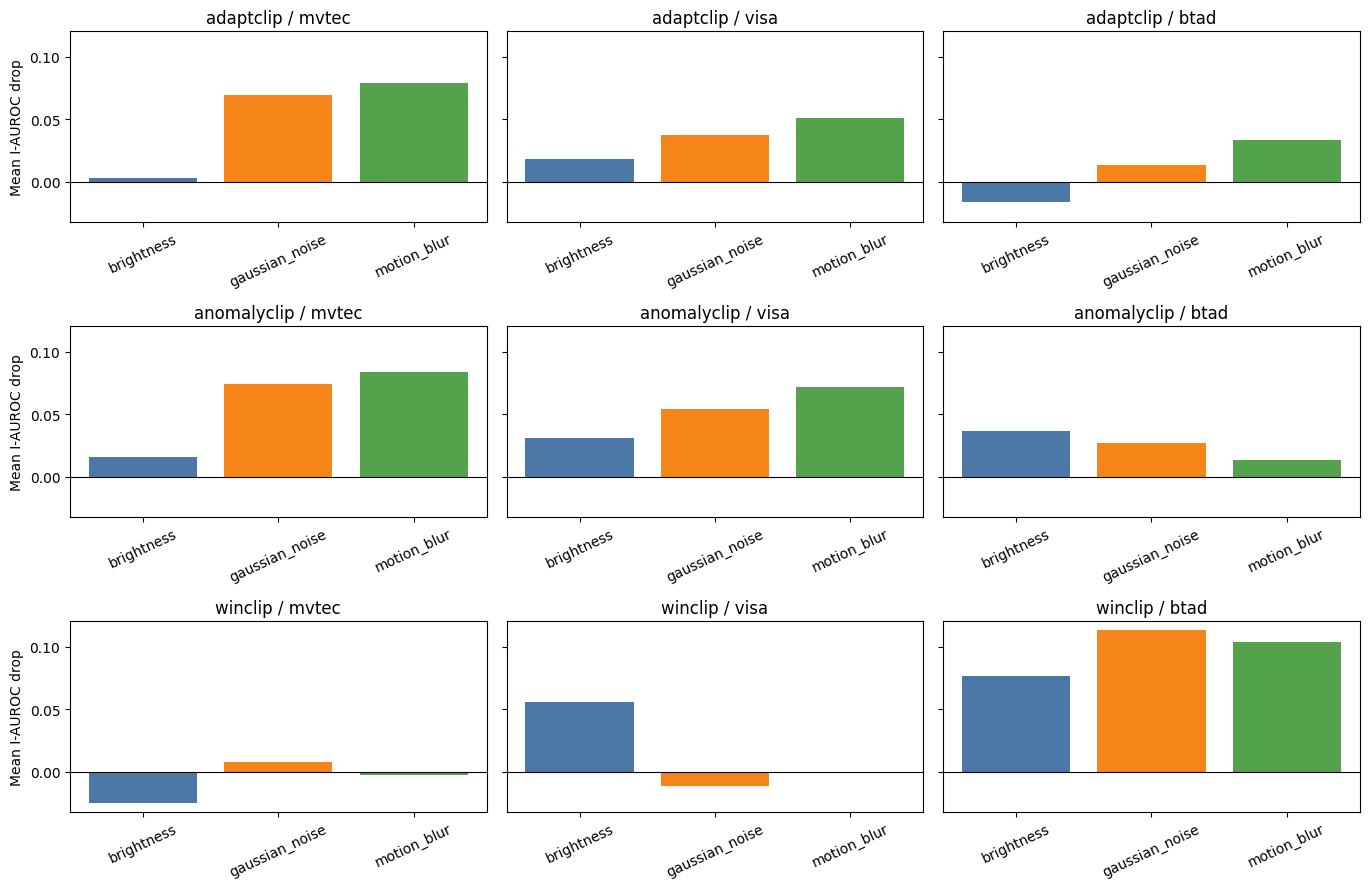

In [148]:
def plot_mean_drop(metric="I-AUROC"):
    summary = mean_drop_summary(metric)
    fig, axes = plt.subplots(len(MODELS), len(DATASETS), figsize=(14, 9), sharey=True)

    for row_idx, model in enumerate(MODELS):
        for col_idx, dataset in enumerate(DATASETS):
            ax = axes[row_idx, col_idx]
            part = summary[(summary["model"].eq(model)) & (summary["dataset"].eq(dataset))]
            ax.bar(part["corruption"], part["drop"], color=["#4C78A8", "#F58518", "#54A24B"])
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_title(f"{model} / {dataset}")
            ax.tick_params(axis="x", rotation=25)
            if col_idx == 0:
                ax.set_ylabel(f"Mean {metric} drop")

    fig.tight_layout()
    return fig


plot_mean_drop("I-AUROC")


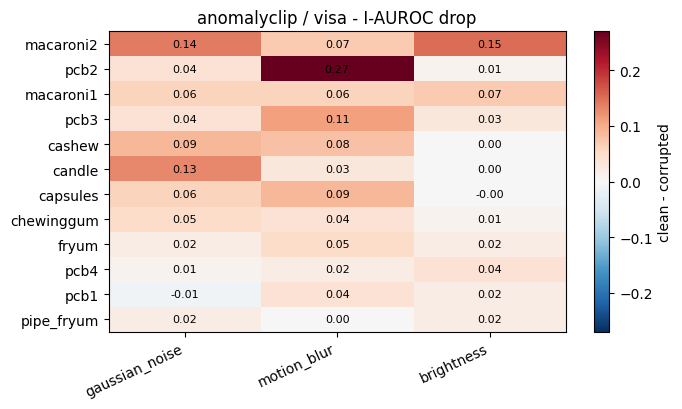

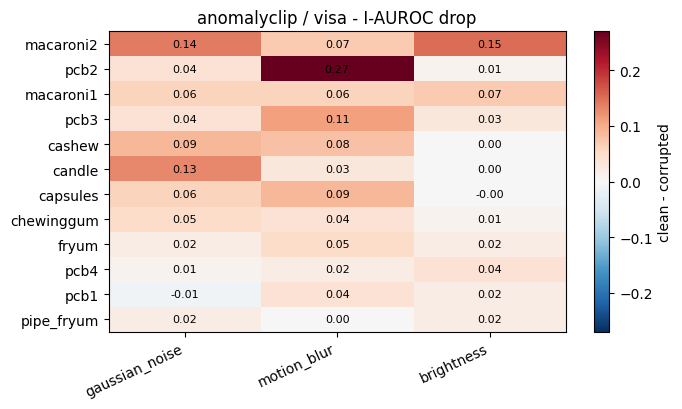

In [ ]:
def drop_matrix(model, dataset, metric="I-AUROC"):
    drops = all_drop_table(model, dataset, metric=metric)
    matrix = drops.pivot(index="class", columns="corruption", values="drop")
    matrix = matrix[["gaussian_noise", "motion_blur", "brightness"]]
    matrix["mean_drop"] = matrix.mean(axis=1)
    return matrix.sort_values("mean_drop", ascending=False).drop(columns="mean_drop")


def plot_drop_heatmap(model, dataset, metric="I-AUROC"):
    matrix = drop_matrix(model, dataset, metric)
    fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(matrix))))
    vmax = max(abs(matrix.min().min()), abs(matrix.max().max()))
    image = ax.imshow(matrix.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    ax.set_title(f"{model} / {dataset} - {metric} drop")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    for y in range(matrix.shape[0]):
        for x in range(matrix.shape[1]):
            ax.text(x, y, f"{matrix.iloc[y, x]:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label="clean - corrupted")
    fig.tight_layout()
    return fig


plot_drop_heatmap("anomalyclip", "visa")


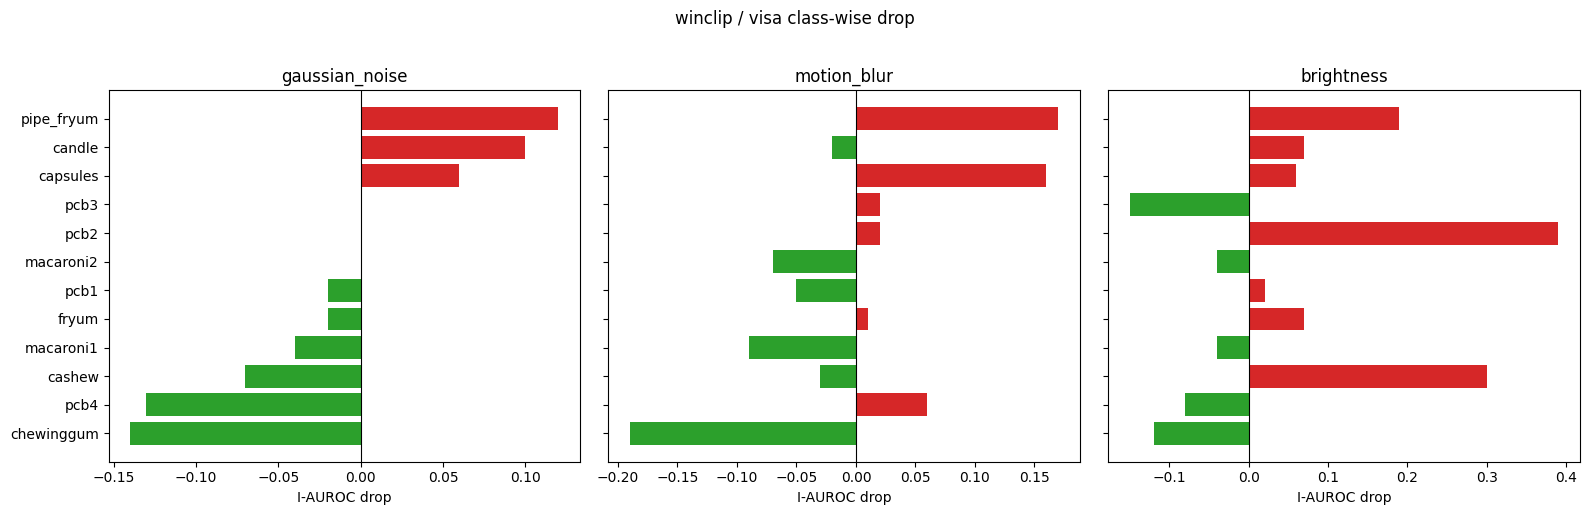

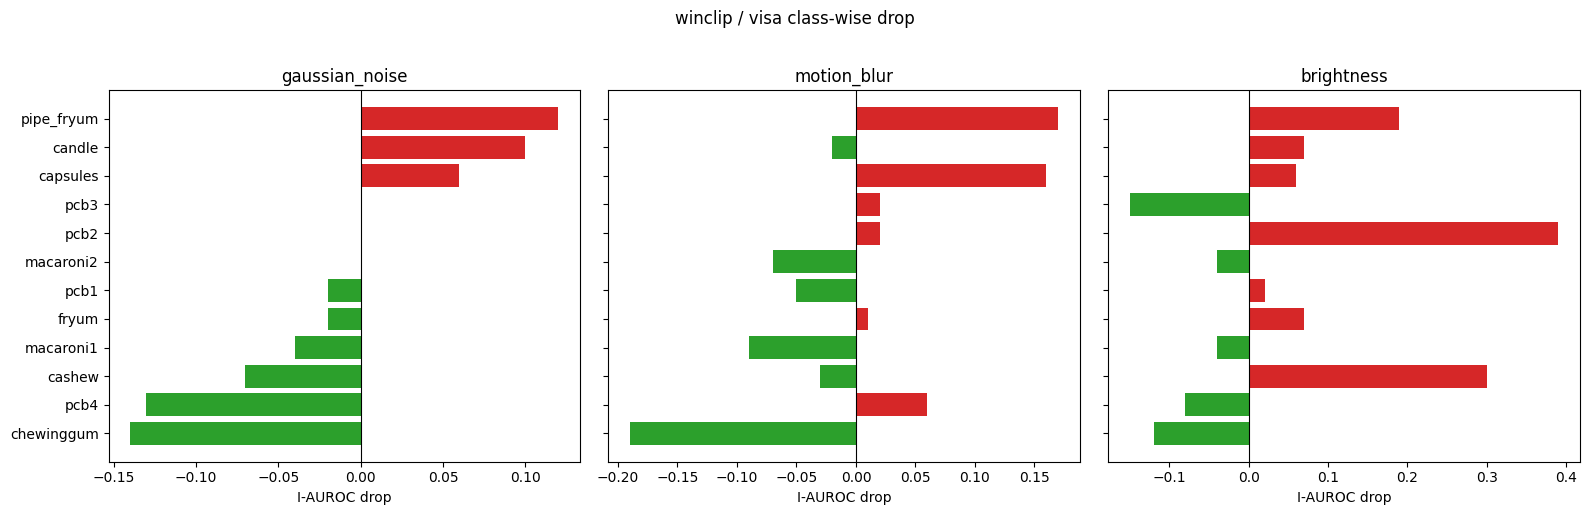

In [ ]:
def plot_class_drop_bars(model, dataset, metric="I-AUROC"):
    drops = all_drop_table(model, dataset, metric=metric)
    corruptions = ["gaussian_noise", "motion_blur", "brightness"]
    fig, axes = plt.subplots(1, len(corruptions), figsize=(16, max(5, 0.35 * drops["class"].nunique())), sharey=True)

    for ax, corruption in zip(axes, corruptions):
        part = drops[drops["corruption"].eq(corruption)].sort_values("drop", ascending=True)
        colors = ["#D62728" if value >= 0 else "#2CA02C" for value in part["drop"]]
        ax.barh(part["class"], part["drop"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(corruption)
        ax.set_xlabel(f"{metric} drop")

    fig.suptitle(f"{model} / {dataset} class-wise drop", y=1.02)
    fig.tight_layout()
    return fig


plot_class_drop_bars("winclip", "btad")


## Plot Other Pairs
Change the model and dataset names below to draw the same graphs for another pair.

In [ ]:
model = "adaptclip"
dataset = "mvtec"

plot_drop_heatmap(model, dataset)
plot_class_drop_bars(model, dataset)


## Clean-to-Corruption Category Drop Bar Plots
These plots compare clean category difficulty scores against each corrupted condition. Values are category-level mean I-AUROC drops: clean minus corrupted. Larger positive values mean the category became harder under corruption.

In [151]:
def category_condition_scores(metric="I-AUROC", split="all"):
    rows = []
    for condition in CONDITIONS:
        scores = (
            raw[raw["split"].eq(split) & raw["corruption"].eq(condition)]
            .groupby(["dataset", "class"], as_index=False)[metric]
            .mean()
            .rename(columns={metric: condition})
        )
        rows.append(scores)

    merged = rows[0]
    for item in rows[1:]:
        merged = merged.merge(item, on=["dataset", "class"], how="inner")

    merged["category"] = merged["dataset"] + " / " + merged["class"].astype(str)
    return merged


def category_drop_table(metric="I-AUROC", split="all", decimals=2):
    scores = category_condition_scores(metric, split)
    for condition in [c for c in CONDITIONS if c != "clean"]:
        scores[f"clean-{condition}"] = scores["clean"] - scores[condition]

    clean_order = clean_difficulty_by_category(metric, split, decimals=6)[["dataset", "class", "rank", "difficulty"]]
    out = clean_order.merge(scores, on=["dataset", "class"], how="left")
    drop_cols = [f"clean-{condition}" for condition in CONDITIONS if condition != "clean"]
    out[["clean"] + [c for c in CONDITIONS if c != "clean"] + drop_cols] = out[
        ["clean"] + [c for c in CONDITIONS if c != "clean"] + drop_cols
    ].round(decimals)
    return out[["rank", "difficulty", "dataset", "class", "category", "clean"] + [c for c in CONDITIONS if c != "clean"] + drop_cols]


category_drops_i_auroc = category_drop_table("I-AUROC")
category_drops_i_auroc


,rank,difficulty,dataset,class,category,clean,gaussian_noise,motion_blur,brightness,clean-gaussian_noise,clean-motion_blur,clean-brightness
0,1,hard,visa,pcb3,visa / pcb3,0.64,0.61,0.58,0.65,0.03,0.06,-0.02
1,2,hard,visa,macaroni2,visa / macaroni2,0.66,0.60,0.65,0.61,0.06,0.01,0.05
2,3,hard,visa,macaroni1,visa / macaroni1,0.69,0.70,0.71,0.69,-0.01,-0.02,-0.00
3,4,hard,visa,pcb2,visa / pcb2,0.69,0.66,0.55,0.55,0.03,0.14,0.14
4,5,hard,mvtec,screw,mvtec / screw,0.70,0.58,0.48,0.75,0.11,0.22,-0.05
5,6,hard,visa,cashew,visa / cashew,0.72,0.70,0.72,0.63,0.02,0.01,0.10
6,7,hard,mvtec,transistor,mvtec / transistor,0.73,0.64,0.63,0.72,0.09,0.10,0.01
7,8,hard,mvtec,cable,mvtec / cable,0.73,0.69,0.73,0.72,0.05,0.00,0.01
8,9,hard,mvtec,pill,mvtec / pill,0.74,0.58,0.70,0.75,0.16,0.04,-0.01
9,10,normal,btad,2,btad / 2,0.74,0.64,0.66,0.72,0.11,0.09,0.02


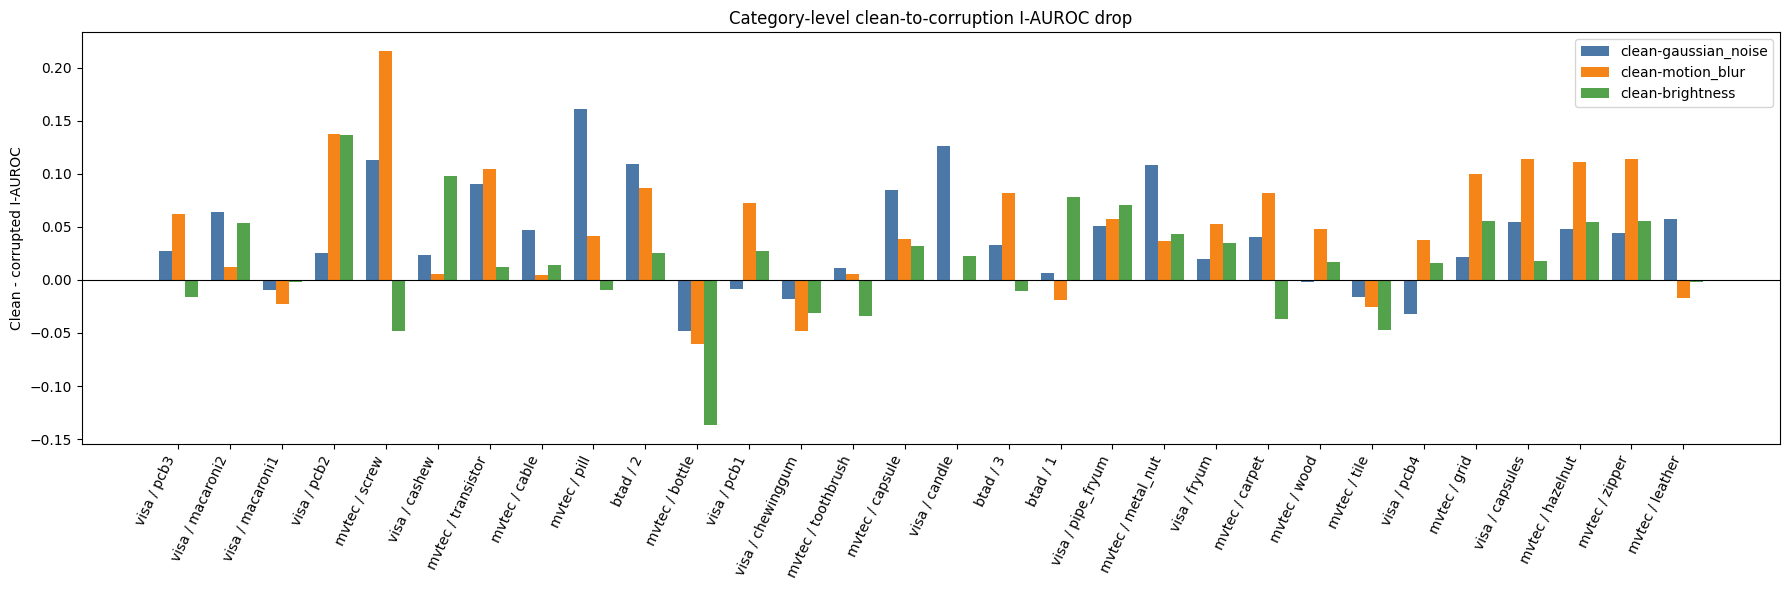

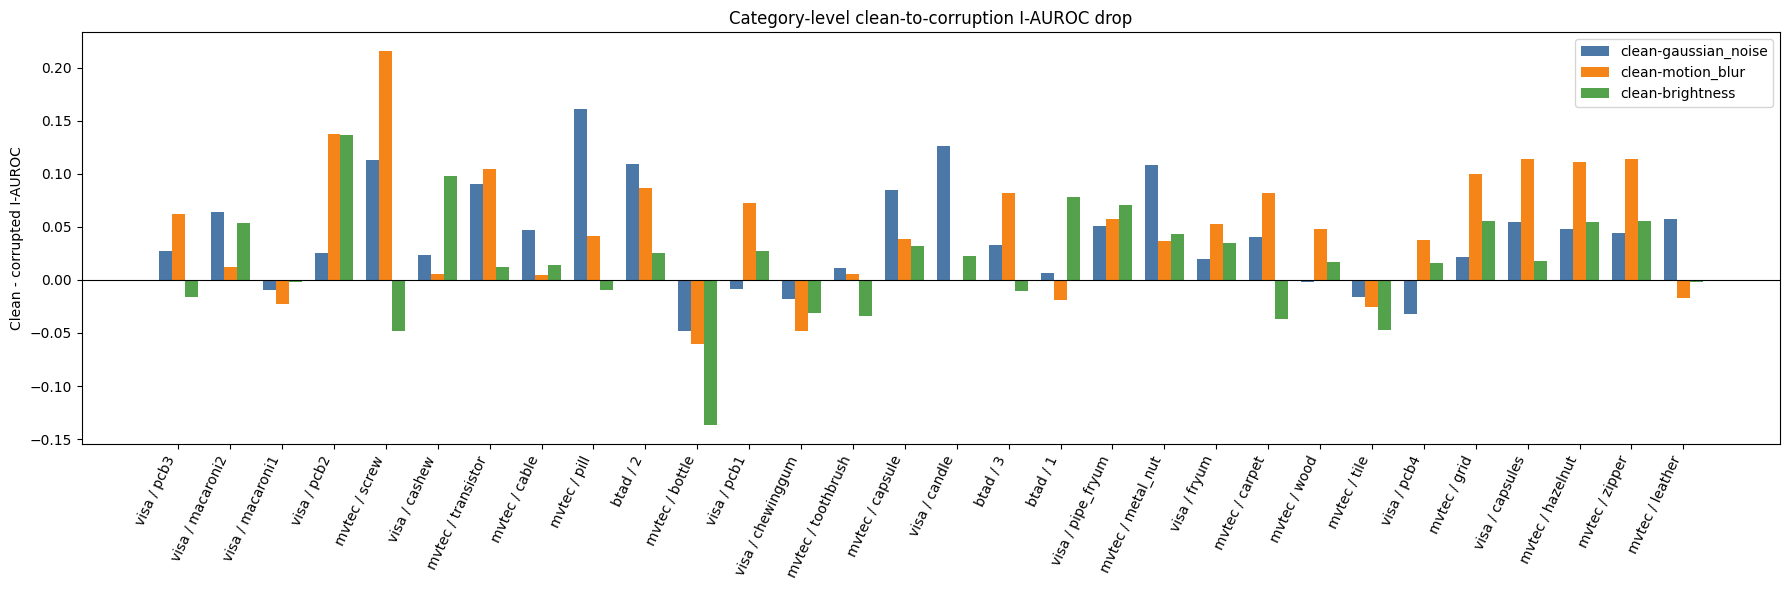

In [153]:
def plot_category_drop_grouped(metric="I-AUROC", split="all"):
    table = category_drop_table(metric, split, decimals=6).sort_values("rank")
    drop_cols = [f"clean-{condition}" for condition in CONDITIONS if condition != "clean"]
    labels = table["category"].tolist()
    x = range(len(table))
    width = 0.25
    colors = ["#4C78A8", "#F58518", "#54A24B"]

    fig, ax = plt.subplots(figsize=(18, 6))
    for idx, (col, color) in enumerate(zip(drop_cols, colors)):
        offset = (idx - 1) * width
        ax.bar([pos + offset for pos in x], table[col], width=width, label=col, color=color)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=65, ha="right")
    ax.set_ylabel(f"Clean - corrupted {metric}")
    ax.set_title(f"Category-level clean-to-corruption {metric} drop")
    ax.legend()
    fig.tight_layout()
    return fig


plot_category_drop_grouped("I-AUROC")


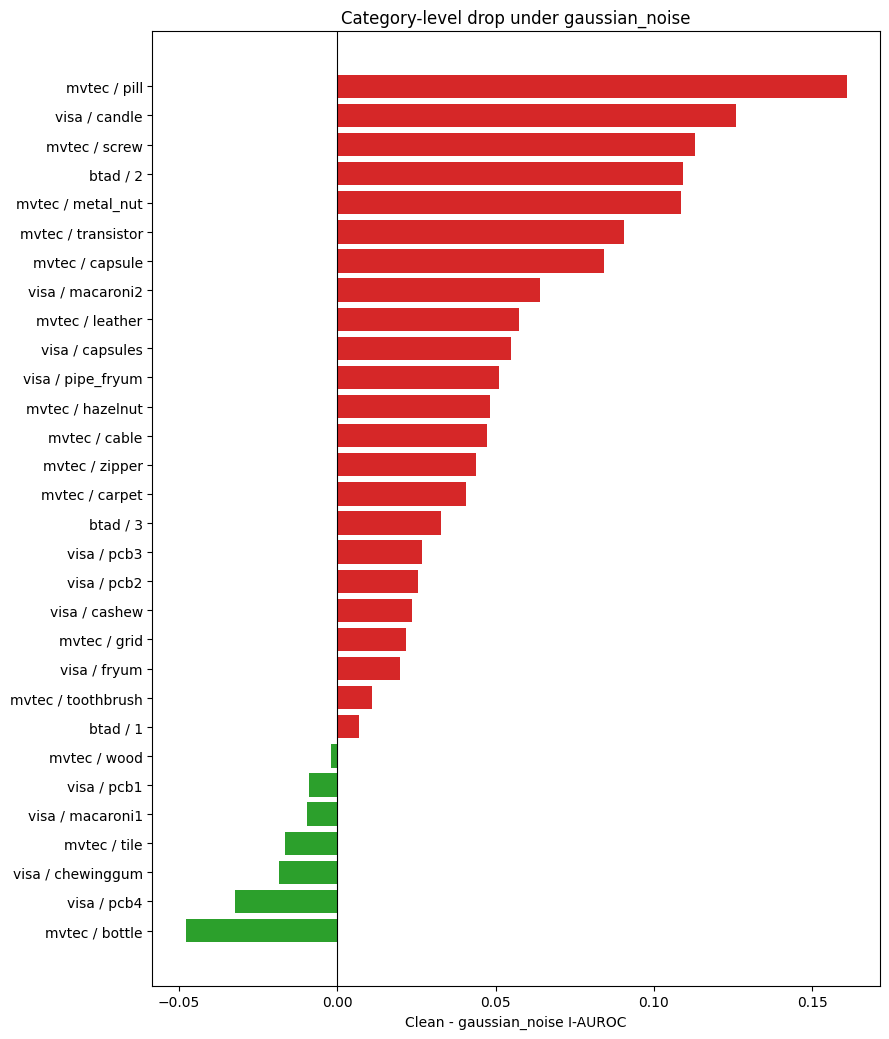

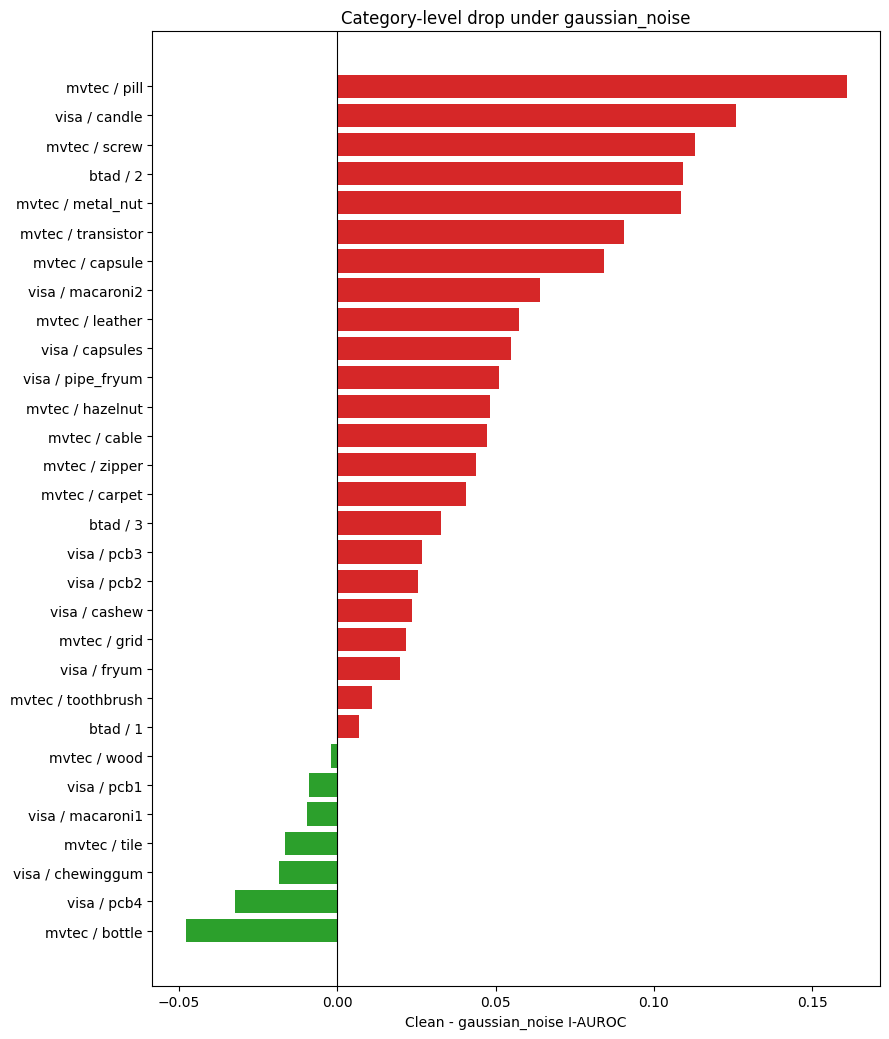

In [152]:
def plot_category_drop_by_corruption(corruption, metric="I-AUROC", split="all", top_n=None):
    col = f"clean-{corruption}"
    table = category_drop_table(metric, split, decimals=6).sort_values(col, ascending=True)
    if top_n is not None:
        table = table.tail(top_n)

    colors = ["#D62728" if value >= 0 else "#2CA02C" for value in table[col]]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.35 * len(table))))
    ax.barh(table["category"], table[col], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Clean - {corruption} {metric}")
    ax.set_title(f"Category-level drop under {corruption}")
    fig.tight_layout()
    return fig


plot_category_drop_by_corruption("gaussian_noise")


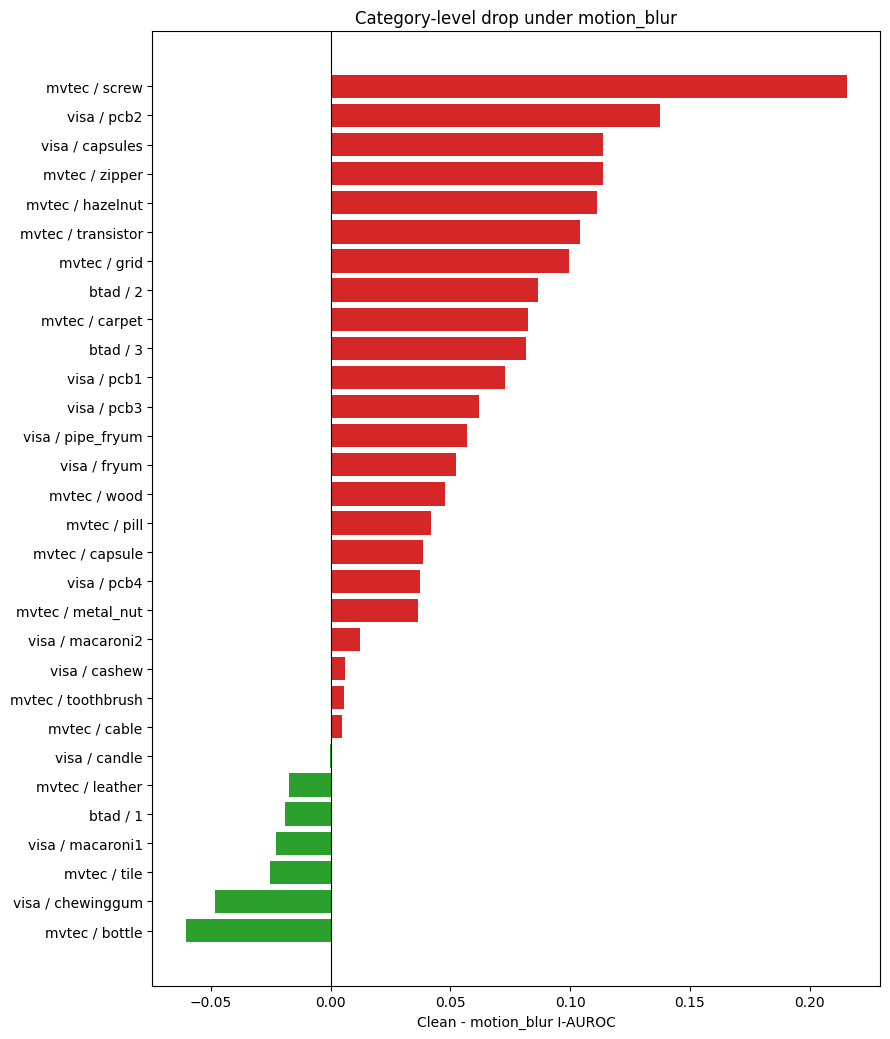

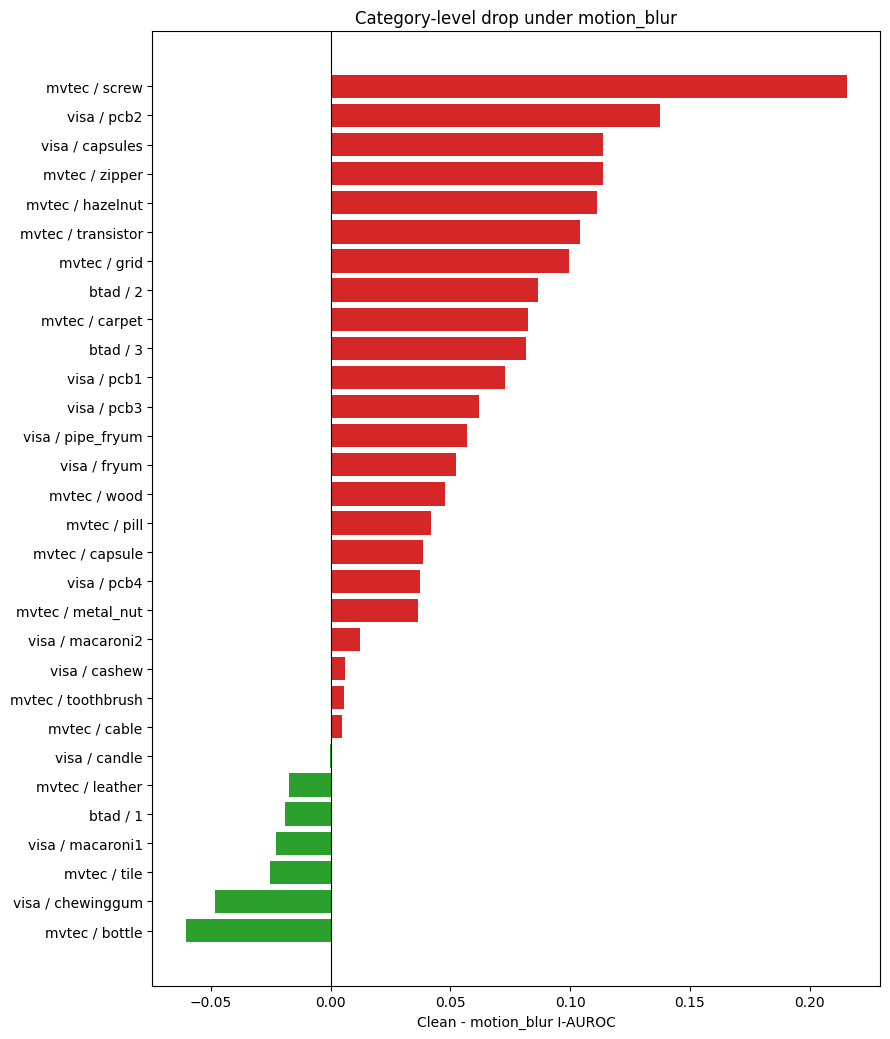

In [154]:
plot_category_drop_by_corruption("motion_blur")


In [ ]:
plot_category_drop_by_corruption("brightness")


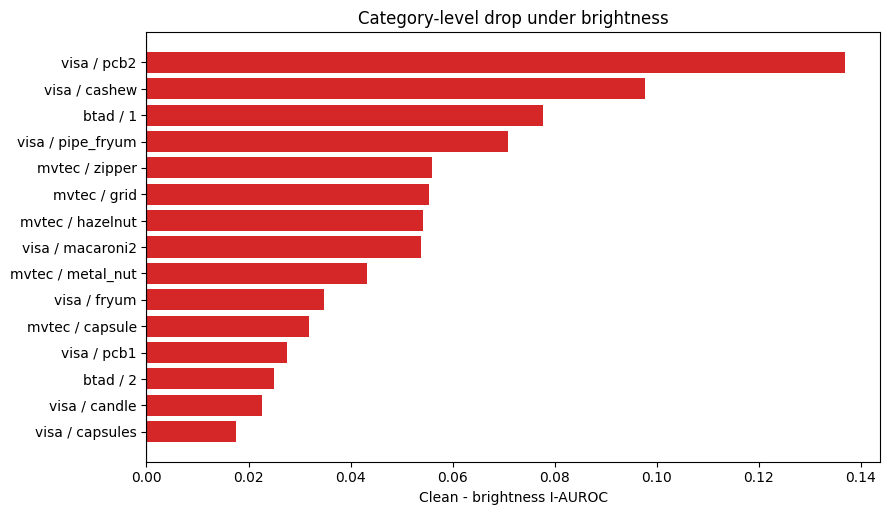

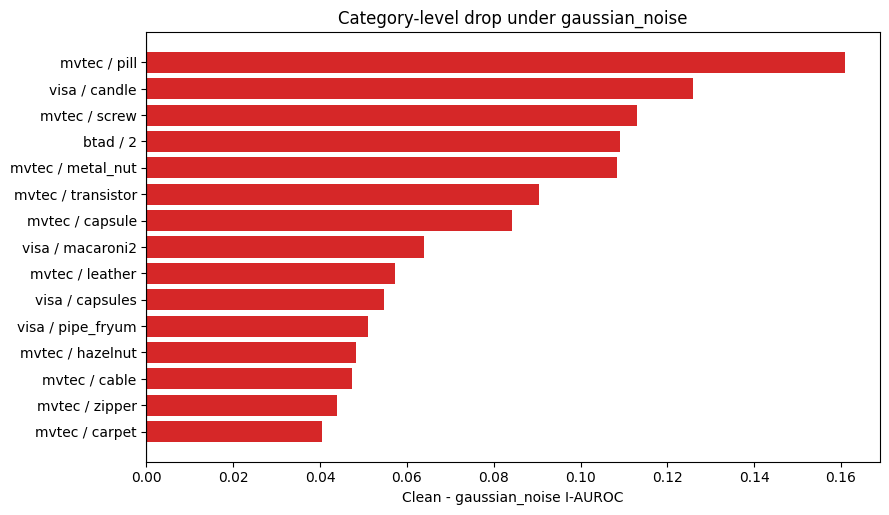

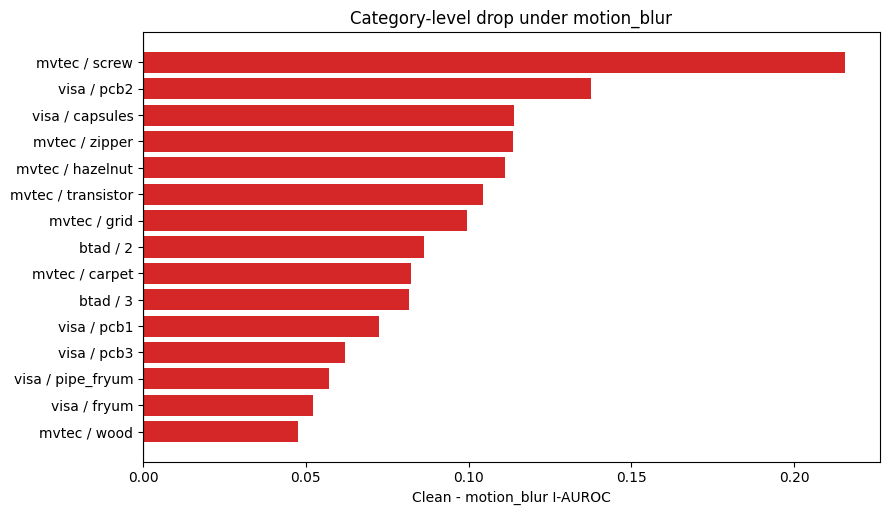

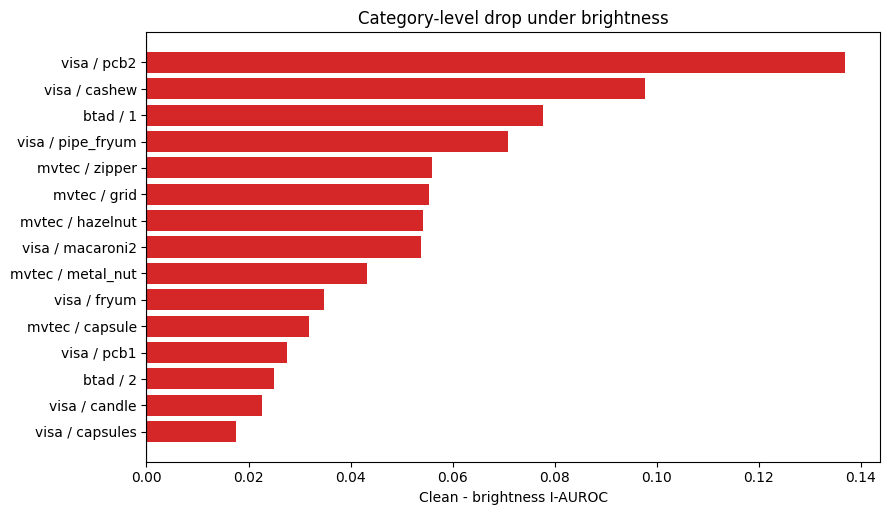

In [155]:
# Cleaner version for papers/slides: show only the largest drops.
plot_category_drop_by_corruption("gaussian_noise", top_n=15)
plot_category_drop_by_corruption("motion_blur", top_n=15)
plot_category_drop_by_corruption("brightness", top_n=15)
